<a href="https://colab.research.google.com/github/swayambel/orbital-integrator-stability-checker/blob/main/orbital_integrators.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Symplectic vs Non-Symplectic Integrators for Orbital Motion

---

**Author:** Swayam Beluse

**Topic:** Numerical Integration of the Two-Body Gravitational Problem  

**Tools:** Python · NumPy · Matplotlib

---


## 1. Overview

This notebook presents a comparative study of four classical numerical integrators applied to the two-body gravitational problem. Two of the integrators — **Velocity Verlet** and **Leapfrog** — are *symplectic*, meaning they are designed to preserve the geometric (Hamiltonian) structure of the equations of motion. The other two — **RK4** and **Heun's method**.
The central question explored here is:

> **Do symplectic integrators conserve energy and maintain orbital stability better than non-symplectic ones over long integration times?**

This is a foundational question in computational celestial mechanics, molecular dynamics, and any field where long-time Hamiltonian dynamics must be simulated faithfully.

## 2. Project Objectives

The objectives of this study are:

1. Implement four numerical integrators: **RK4**, **Heun**, **Velocity Verlet**, and **Leapfrog**.
2. Simulate a circular orbit using normalized gravitational units ($GM = 1$).
3. Compare **energy conservation** over 15,000 timesteps.
4. Analyze **orbital radius drift** as a proxy for trajectory stability.
5. Monitor **angular momentum conservation** as an additional diagnostic of numerical stability.
6. Inspect **phase-space structure** to understand geometric preservation.
7. Perform a **timestep sensitivity analysis** to characterize how each integrator degrades with larger $\Delta t$.

## 3. Physical Model

We study the classical **two-body gravitational problem**, reduced to the motion of a test particle in the gravitational field of a fixed central mass. This is one of the simplest non-trivial dynamical systems, yet it is a canonical benchmark for numerical integrators.

The system is a **Hamiltonian system** with the following energy:

$$H = \frac{1}{2}(v_x^2 + v_y^2) - \frac{GM}{|\mathbf{r}|}$$

where $\mathbf{r} = (x, y)$ is the position vector and $\mathbf{v} = (v_x, v_y)$ is the velocity. The total energy $H$ is a **conserved quantity** of the exact dynamics. Any numerical drift in $H$ over time is an artifact of the integrator, not the physics.

Symplectic integrators are constructed to preserve a *modified* Hamiltonian that is close to the true one, resulting in **bounded energy oscillations** rather than secular (monotonic) drift. Non-symplectic integrators have no such guarantee.

## 4. Equations of Motion

The equations of motion in Cartesian coordinates are:

$$\frac{d^2 \mathbf{r}}{dt^2} = -\frac{GM\, \mathbf{r}}{|\mathbf{r}|^3}$$

Decomposed into components:

$$\ddot{x} = -\frac{GM\, x}{(x^2 + y^2)^{3/2}}, \qquad \ddot{y} = -\frac{GM\, y}{(x^2 + y^2)^{3/2}}$$

We use normalized units with $GM = 1$, so the equations simplify to:

$$\ddot{\mathbf{r}} = -\frac{\mathbf{r}}{|\mathbf{r}|^3}$$

The specific orbital energy (energy per unit mass) is:

$$E = \frac{1}{2}|\mathbf{v}|^2 - \frac{1}{|\mathbf{r}|}$$

For a circular orbit at $r = 1$ with $v = 1$, the exact energy is $E_0 = -0.5$.

## 5. Initial Conditions

We initialize the orbit with:

| Quantity | Value |
|----------|-------|
| $x_0$ | $1.0$ |
| $y_0$ | $0.0$ |
| $v_{x,0}$ | $0.0$ |
| $v_{y,0}$ | $1.0$ |
| $GM$ | $1.0$ |
| $\Delta t$ | $0.05$ |
| Steps | $15000$ |

These initial conditions satisfy the circular orbit condition $v = \sqrt{GM/r} = 1$, giving an orbital period of $T = 2\pi \approx 6.28$ time units. The simulation covers approximately **1194 orbital periods**, making energy conservation a stringent test.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import LogLocator

plt.style.use("seaborn-v0_8-darkgrid")

COLORS = {
    "RK4":            "#E07B54",
    "Heun":           "#C94040",
    "Velocity Verlet":"#4A90D9",
    "Leapfrog":       "#2ECC71",
}

GM   = 1.0
x0   = 1.0
y0   = 0.0
vx0  = 0.0
vy0  = 1.0
dt   = 0.05
steps = 15000

print(f"Orbital period T = {2*np.pi:.4f}")
print(f"Total time      = {dt*steps:.1f}")
print(f"Orbital periods = {dt*steps/(2*np.pi):.1f}")
print(f"Exact energy E0 = {0.5*vy0**2 - GM/x0:.4f}")

Orbital period T = 6.2832
Total time      = 750.0
Orbital periods = 119.4
Exact energy E0 = -0.5000


## 6. Description of Numerical Integrators

### 6.1 Heun's Method (RK2 Predictor-Corrector)
Heun's method is a second-order Runge-Kutta scheme. It first takes a full Euler step to predict the state at $t + \Delta t$, then averages the slopes at the beginning and end of the interval. It is **non-symplectic** and known to exhibit **energy growth** in conservative systems — the orbit will spiral outward over time.

### 6.2 Runge-Kutta 4 (RK4)
RK4 is the workhorse of scientific computing — a fourth-order, non-symplectic method. It evaluates the derivative at four intermediate points per step, achieving excellent short-time accuracy. However, it is **not symplectic**, so it does not preserve the Hamiltonian structure. Over long integrations it will exhibit slow but nonzero energy drift.

### 6.3 Velocity Verlet
Velocity Verlet is a second-order **symplectic** integrator derived from the Störmer-Verlet splitting. It updates positions using current velocities and accelerations, then updates velocities using a half-step average. It preserves the symplectic 2-form, guaranteeing **bounded energy oscillations** — no secular drift.

### 6.4 Leapfrog (Kick-Drift-Kick)
The Leapfrog integrator is also a second-order symplectic method. It staggers position and velocity updates by half a timestep: positions and velocities are never synchronized, but this "out-of-phase" update is exactly what preserves the symplectic structure. Like Velocity Verlet, it shows **no secular energy drift** and is the method of choice in long-duration simulations.

## 7. Implementation of Integrators

In [ ]:
def acceleration(x, y):
    r3 = (x**2 + y**2)**1.5
    return -GM * x / r3, -GM * y / r3

def specific_energy(x, y, vx, vy):
    r = np.sqrt(x**2 + y**2)
    return 0.5 * (vx**2 + vy**2) - GM / r

def radius(x, y):
    return np.sqrt(x**2 + y**2)

def angular_momentum(x, y, vx, vy):
    return x*vy - y*vx

def step_heun(x, y, vx, vy, dt):
    ax0, ay0 = acceleration(x, y)
    xp  = x  + vx  * dt
    yp  = y  + vy  * dt
    vxp = vx + ax0 * dt
    vyp = vy + ay0 * dt
    ax1, ay1 = acceleration(xp, yp)
    x_new  = x  + 0.5 * (vx  + vxp) * dt
    y_new  = y  + 0.5 * (vy  + vyp) * dt
    vx_new = vx + 0.5 * (ax0 + ax1) * dt
    vy_new = vy + 0.5 * (ay0 + ay1) * dt
    return x_new, y_new, vx_new, vy_new


def step_rk4(x, y, vx, vy, dt):
    def deriv(x, y, vx, vy):
        ax, ay = acceleration(x, y)
        return vx, vy, ax, ay

    k1 = deriv(x, y, vx, vy)
    k2 = deriv(x + 0.5*dt*k1[0], y + 0.5*dt*k1[1],
               vx + 0.5*dt*k1[2], vy + 0.5*dt*k1[3])
    k3 = deriv(x + 0.5*dt*k2[0], y + 0.5*dt*k2[1],
               vx + 0.5*dt*k2[2], vy + 0.5*dt*k2[3])
    k4 = deriv(x + dt*k3[0], y + dt*k3[1],
               vx + dt*k3[2], vy + dt*k3[3])

    c = dt / 6.0
    x_new  = x  + c*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
    y_new  = y  + c*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1])
    vx_new = vx + c*(k1[2] + 2*k2[2] + 2*k3[2] + k4[2])
    vy_new = vy + c*(k1[3] + 2*k2[3] + 2*k3[3] + k4[3])
    return x_new, y_new, vx_new, vy_new


def step_velocity_verlet(x, y, vx, vy, dt):
    ax0, ay0 = acceleration(x, y)
    x_new  = x  + vx  * dt + 0.5 * ax0 * dt**2
    y_new  = y  + vy  * dt + 0.5 * ay0 * dt**2
    ax1, ay1 = acceleration(x_new, y_new)
    vx_new = vx + 0.5 * (ax0 + ax1) * dt
    vy_new = vy + 0.5 * (ay0 + ay1) * dt
    return x_new, y_new, vx_new, vy_new


def step_leapfrog(x, y, vx_half, vy_half, dt):
    x_new  = x + vx_half * dt
    y_new  = y + vy_half * dt
    ax, ay = acceleration(x_new, y_new)
    vx_new = vx_half + ax * dt
    vy_new = vy_half + ay * dt
    return x_new, y_new, vx_new, vy_new


## 8. Orbit Simulation

We now run all four integrators for 15,000 steps with $\Delta t = 0.05$. For the Leapfrog integrator, we initialize the half-step velocity using a single forward Euler kick by $\Delta t / 2$, which staggers the velocity ahead of the position update as required by the leapfrog scheme.

In [ ]:
def run_integrator(integrator_name, steps=steps, dt=dt):
    xs  = np.zeros(steps + 1)
    ys  = np.zeros(steps + 1)
    vxs = np.zeros(steps + 1)
    vys = np.zeros(steps + 1)

    xs[0], ys[0], vxs[0], vys[0] = x0, y0, vx0, vy0

    if integrator_name == "Leapfrog":
        ax0, ay0 = acceleration(x0, y0)
        vx_h = vx0 + 0.5 * dt * ax0
        vy_h = vy0 + 0.5 * dt * ay0
        for i in range(steps):
            xs[i+1], ys[i+1], vx_h, vy_h = step_leapfrog(xs[i], ys[i], vx_h, vy_h, dt)
            ax, ay = acceleration(xs[i+1], ys[i+1])
            vxs[i+1] = vx_h - 0.5 * dt * ax
            vys[i+1] = vy_h - 0.5 * dt * ay
    else:
        step_fn = {"RK4": step_rk4, "Heun": step_heun, "Velocity Verlet": step_velocity_verlet}[integrator_name]
        for i in range(steps):
            xs[i+1], ys[i+1], vxs[i+1], vys[i+1] = step_fn(xs[i], ys[i], vxs[i], vys[i], dt)

    return xs, ys, vxs, vys


results = {}
for name in ["RK4", "Heun", "Velocity Verlet", "Leapfrog"]:
    xs, ys, vxs, vys = run_integrator(name)
    E = specific_energy(xs, ys, vxs, vys)
    R = radius(xs, ys)
    L = angular_momentum(xs, ys, vxs, vys)
    results[name] = {"x": xs, "y": ys, "vx": vxs, "vy": vys, "E": E, "R": R, "L": L}
    print(f"{name:<20} | E_final = {E[-1]:.6f} | R_final = {R[-1]:.6f}")

E0   = specific_energy(x0, y0, vx0, vy0)
time = np.linspace(0, dt * steps, steps + 1)
print(f"\nExact energy E0 = {E0:.6f}")

RK4                  | E_final = -0.500003 | R_final = 0.999993
Heun                 | E_final = -0.480005 | R_final = 1.045542
Velocity Verlet      | E_final = -0.499999 | R_final = 1.000964
Leapfrog             | E_final = -0.499999 | R_final = 1.000964

Exact energy E0 = -0.500000


### Plot 1 — Orbit Trajectories

The first diagnostic is the simplest: where does the orbit go? A perfect circular orbit should retrace the unit circle indefinitely.

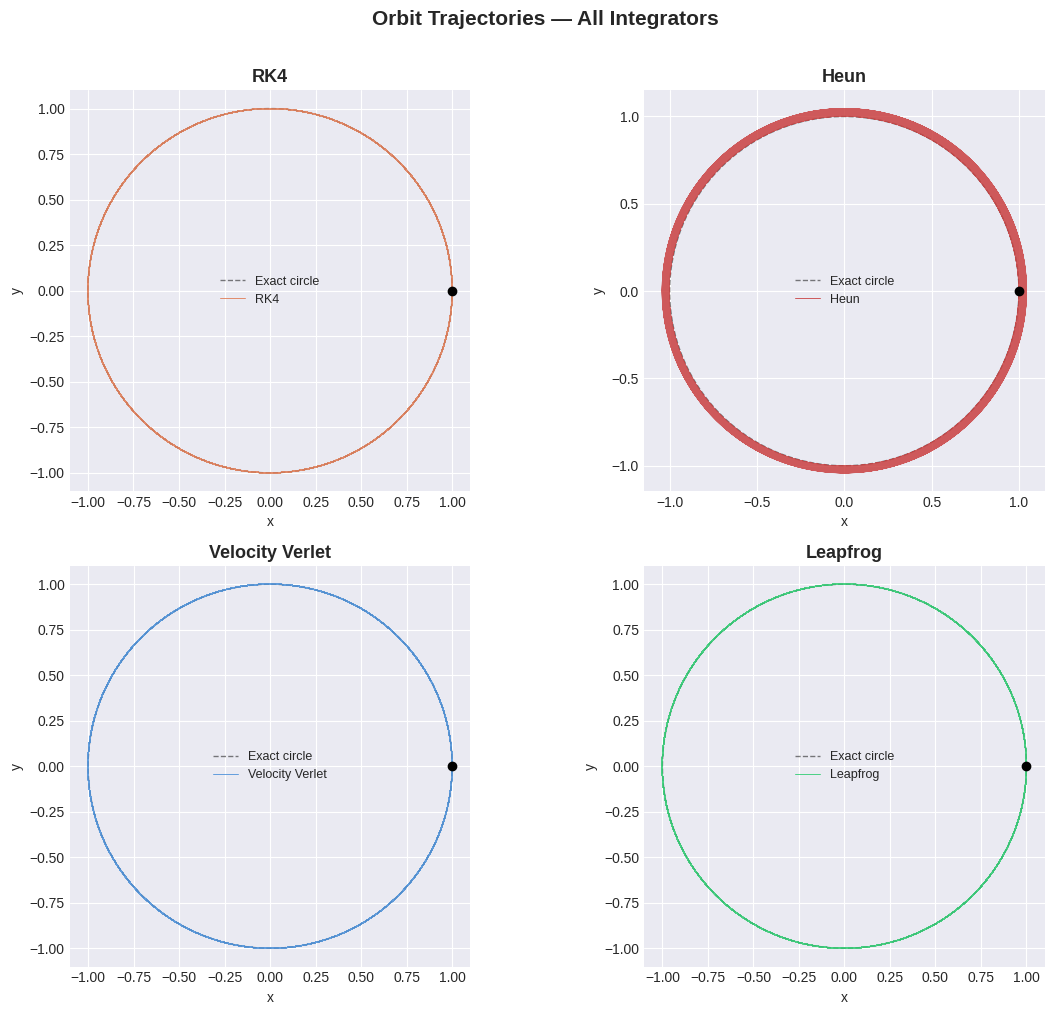

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
theta_ref = np.linspace(0, 2*np.pi, 500)

for ax, (name, data) in zip(axes, results.items()):
    ax.plot(np.cos(theta_ref), np.sin(theta_ref), 'k--', lw=1, alpha=0.5, label='Exact circle')
    ax.plot(data["x"], data["y"], color=COLORS[name], lw=0.7, alpha=0.85, label=name)
    ax.plot(x0, y0, 'ko', ms=6, zorder=5)
    ax.set_aspect('equal')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=9)

fig.suptitle('Orbit Trajectories — All Integrators', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('orbit_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The Heun integrator exhibits a clearly visible outward spiral — the orbit gains energy over time, causing the radius to grow. The RK4 trajectory maintains a visually circular orbit for much longer, but subtle drift may accumulate. The Velocity Verlet and Leapfrog orbits trace a near-perfect circle throughout the simulation, with only imperceptible geometric drift. This immediate visual comparison already hints at the fundamental difference in long-time behavior.

## 9. Energy Conservation Analysis

The total mechanical energy of the orbit should remain constant at $E_0 = -0.5$. We track the **absolute energy error** $|E(t) - E_0|$ as a function of time.

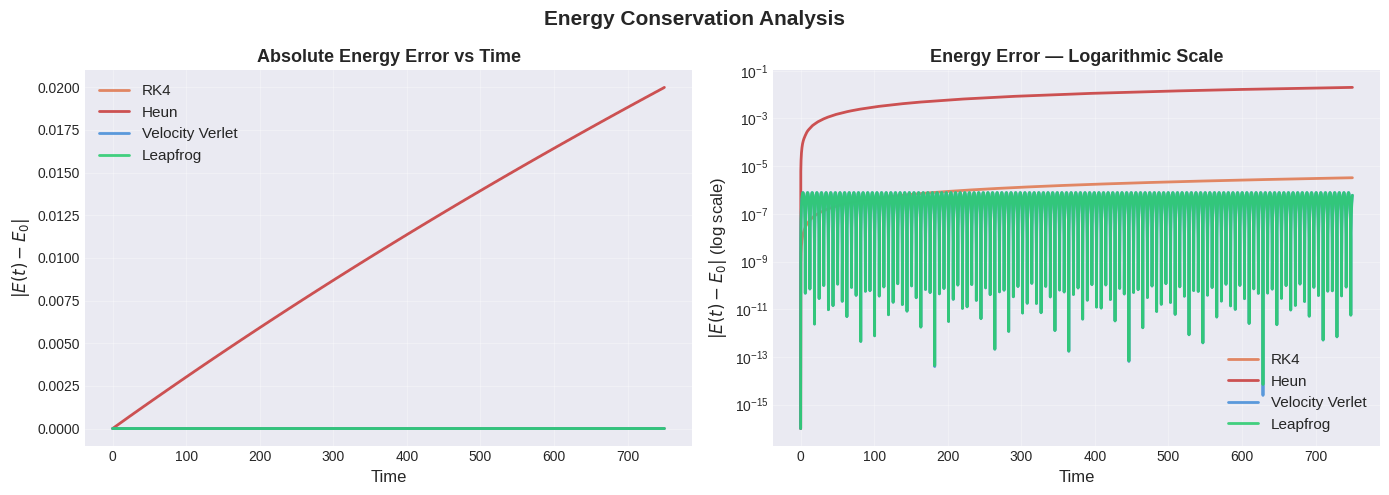

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, data in results.items():
    dE = np.abs(data["E"] - E0)
    axes[0].plot(time, dE, color=COLORS[name], lw=2, alpha=0.9, label=name)

axes[0].set_xlabel('Time', fontsize=12)
axes[0].set_ylabel(r'$|E(t) - E_0|$', fontsize=12)
axes[0].set_title('Absolute Energy Error vs Time', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

for name, data in results.items():
    dE = np.abs(data["E"] - E0)
    dE = np.where(dE < 1e-16, 1e-16, dE)
    axes[1].semilogy(time, dE, color=COLORS[name], lw=2, alpha=0.9, label=name)

axes[1].set_xlabel('Time', fontsize=12)
axes[1].set_ylabel(r'$|E(t) - E_0|$ (log scale)', fontsize=12)
axes[1].set_title('Energy Error — Logarithmic Scale', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3, which='both')

plt.suptitle('Energy Conservation Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('energy_conservation.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The energy analysis reveals the core behavioral difference between the integrator classes:

- **Heun** shows a clear **monotonic increase** in energy error — artificial energy injection causes the orbit to spiral outward continuously. On the linear scale it is the dominant signal, growing to $\sim 0.02$ by $t = 750$.
- **RK4** exhibits extremely small energy error that is essentially **invisible on the linear scale**, hidden beneath Heun's growth. On the logarithmic scale, however, a slow but genuine **secular drift** becomes apparent — RK4 is highly accurate per step, but it does not preserve Hamiltonian structure, so the error accumulates secularly over long times.
- **Velocity Verlet** and **Leapfrog** display **bounded oscillations** in energy error that neither grow nor decay. This is the defining signature of a symplectic integrator: the error fluctuates around a constant level rather than drifting away.

Two additional observations are clear from the logarithmic panel: on the log scale, RK4 achieves lower instantaneous error due to its higher-order accuracy, but this error grows secularly over time. In contrast, symplectic methods exhibit bounded error behavior, making Velocity Verlet and Leapfrog more reliable for preserving orbital structure over long integrations. Most strikingly, **Velocity Verlet and Leapfrog produce nearly identical curves throughout** — their complete overlap confirms that these are mathematically equivalent formulations of the same underlying symplectic scheme.

## 10. Radius Drift Analysis

For a circular orbit, the orbital radius should remain constant at $r = 1$. We track $|r(t) - 1|$ to measure how far each orbit drifts from the correct trajectory.

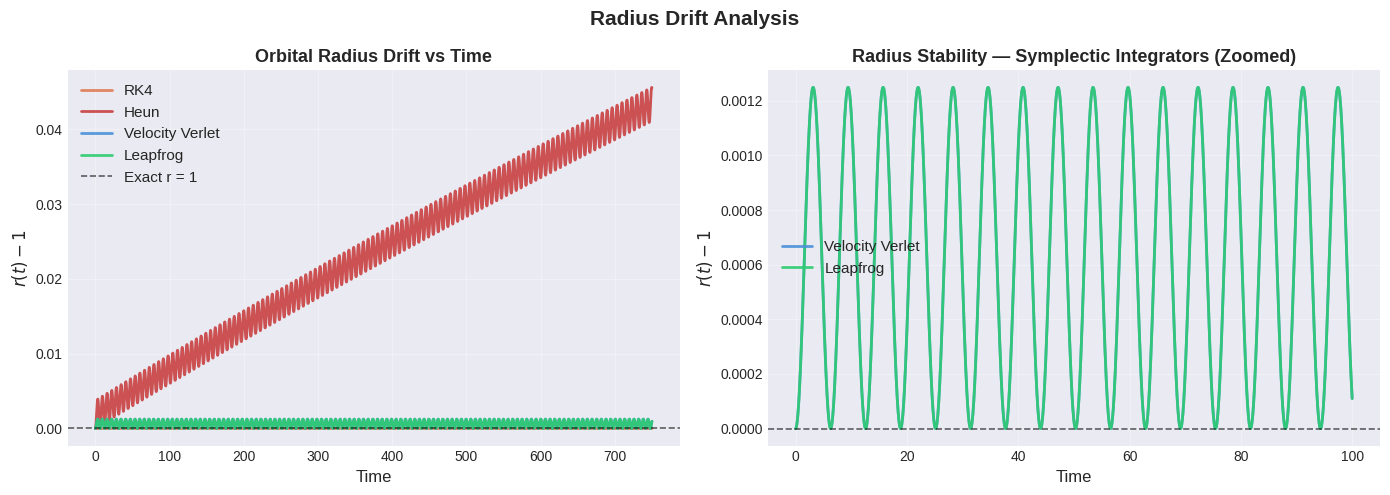

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, data in results.items():
    axes[0].plot(time, data["R"] - 1.0, color=COLORS[name], lw=2, alpha=0.9, label=name)

axes[0].axhline(0, color='black', lw=1.2, ls='--', alpha=0.6, label='Exact r = 1')
axes[0].set_xlabel('Time', fontsize=12)
axes[0].set_ylabel(r'$r(t) - 1$', fontsize=12)
axes[0].set_title('Orbital Radius Drift vs Time', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

zoom_end = min(2000, steps + 1)
for name, data in results.items():
    if name in ["Velocity Verlet", "Leapfrog"]:
        axes[1].plot(time[:zoom_end], data["R"][:zoom_end] - 1.0,
                     color=COLORS[name], lw=2, alpha=0.9, label=name)

axes[1].axhline(0, color='black', lw=1.2, ls='--', alpha=0.6)
axes[1].set_xlabel('Time', fontsize=12)
axes[1].set_ylabel(r'$r(t) - 1$', fontsize=12)
axes[1].set_title('Radius Stability — Symplectic Integrators (Zoomed)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Radius Drift Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('radius_drift.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The radius drift plot dramatically illustrates why integrator choice matters in long-duration simulations:

- **Heun** shows a clear upward trend — the orbit is gradually migrating to a larger radius, consistent with spurious energy injection.
- **RK4** maintains a small but nonzero secular drift. Its higher accuracy per step makes this drift extremely slow, but it is structurally present.
- The **zoomed panel** (right) reveals that Velocity Verlet and Leapfrog overlap almost perfectly, exhibiting identical bounded oscillations around r = 1 with amplitude ~10⁻⁴. This further confirms their equivalence as symplectic integrators.

## 11. Phase Space Structure

We examine a projected phase space in the $(x, v_x)$ plane. For a perfect circular orbit, the trajectory in phase space is an ellipse. Symplectic integrators preserve the **area** of regions in phase space (Liouville's theorem), while non-symplectic integrators may cause the phase-space trajectory to spiral inward or outward.

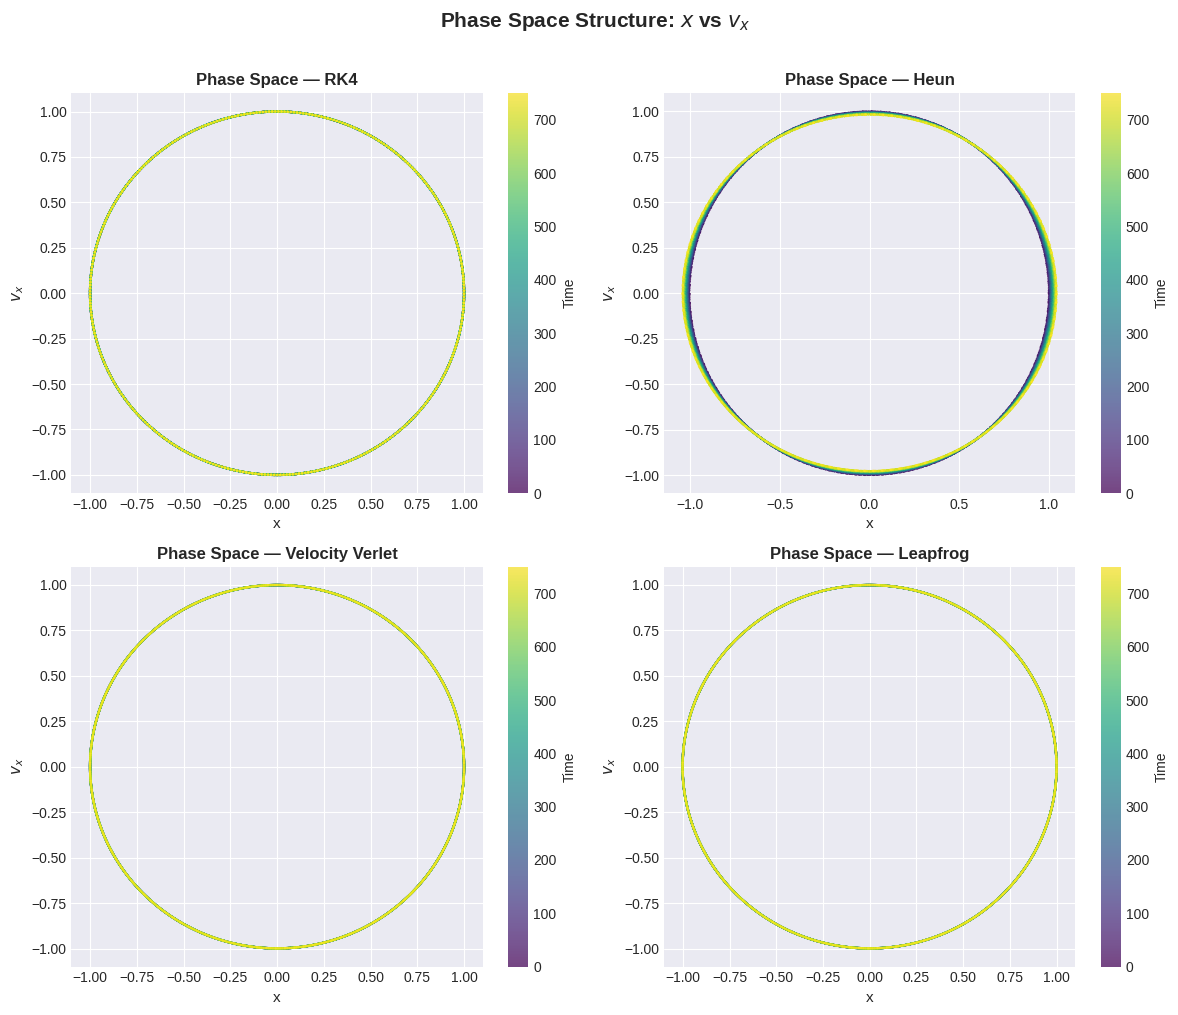

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, data) in zip(axes, results.items()):
    sc = ax.scatter(data["x"], data["vx"],
                    c=time, cmap='viridis', s=0.5, alpha=0.7)
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel(r'$v_x$', fontsize=11)
    ax.set_title(f'Phase Space — {name}', fontsize=12, fontweight='bold')
    plt.colorbar(sc, ax=ax, label='Time')

fig.suptitle(r'Phase Space Structure: $x$ vs $v_x$', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('phase_space.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The phase-space plots carry deep geometric meaning:

- **Heun** shows a spiraling structure — the trajectory gradually migrates to larger amplitude in phase space, indicating continuously growing energy. The color gradient from purple (early) to yellow (late) shows this drift clearly.
- **RK4** shows a near-perfect closed circle with no visible drift — its energy error is too slow to appear at this scale.
- **Velocity Verlet** and **Leapfrog** produce a beautifully sharp, closed circle — the trajectory revisits exactly the same region of phase space indefinitely. This is the geometric signature of **symplecticity**: area preservation in phase space.

Symplectic integrators do not merely conserve energy better — they preserve the *topology* of the phase-space flow.

## 12. Angular Momentum Conservation

In a central force system such as gravity, **angular momentum is exactly conserved** — it is a first integral arising from the rotational symmetry of the potential (Noether's theorem). The specific angular momentum is:

$$L = x\, v_y - y\, v_x$$

For our circular orbit, $L_0 = x_0 v_{y,0} - y_0 v_{x,0} = 1 \times 1 - 0 = 1$.

Monitoring the deviation $|L(t) - L_0|$ over time provides an **independent diagnostic** of numerical stability that is complementary to the energy analysis. A method may conserve one quantity better than the other, and inspecting both gives a more complete picture of the integrator's geometric fidelity.

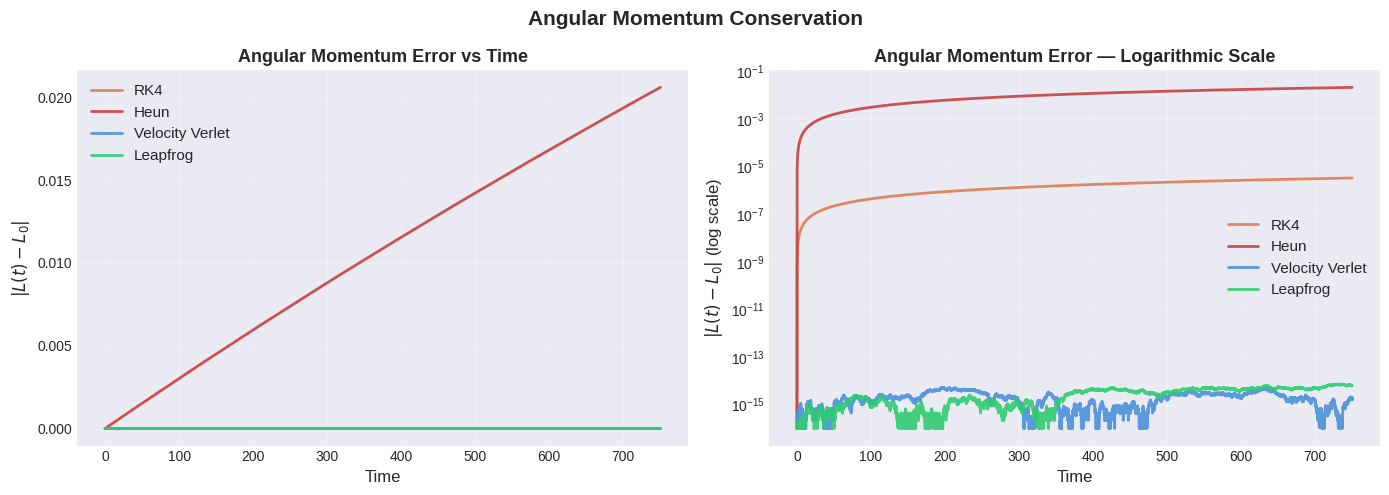

In [ ]:
L0 = angular_momentum(x0, y0, vx0, vy0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, data in results.items():
    dL = np.abs(data["L"] - L0)
    axes[0].plot(time, dL, color=COLORS[name], lw=2, alpha=0.9, label=name)

axes[0].set_xlabel('Time', fontsize=12)
axes[0].set_ylabel(r'$|L(t) - L_0|$', fontsize=12)
axes[0].set_title('Angular Momentum Error vs Time', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

for name, data in results.items():
    dL = np.abs(data["L"] - L0)
    dL = np.where(dL < 1e-16, 1e-16, dL)
    axes[1].semilogy(time, dL, color=COLORS[name], lw=2, alpha=0.9, label=name)

axes[1].set_xlabel('Time', fontsize=12)
axes[1].set_ylabel(r'$|L(t) - L_0|$ (log scale)', fontsize=12)
axes[1].set_title('Angular Momentum Error — Logarithmic Scale', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3, which='both')

plt.suptitle('Angular Momentum Conservation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('angular_momentum.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** Angular momentum conservation reinforces the conclusions drawn from the energy analysis:

- **Heun** exhibits the largest and fastest-growing angular momentum deviation, consistent with the instability observed in both energy and radius. The orbit's spurious energy gain also manifests as a systematic increase in $L$, since a larger orbit carries more angular momentum.
- **RK4** maintains small angular momentum errors initially, but slow secular drift is visible over long integration times — structurally the same behavior seen in the energy error.
- **Velocity Verlet** and **Leapfrog** both again produce nearly identical results, maintaining nearly constant angular momentum throughout the simulation, with only small **bounded oscillations** rather than drift. This is the expected behavior for symplectic integrators: they preserve the geometric structure of the Hamiltonian flow, which naturally keeps conserved quantities bounded.

The agreement between the energy and angular momentum diagnostics strengthens confidence in these conclusions: the qualitative differences between integrator classes are robust across multiple conserved quantities.


## 13. Timestep Stability Analysis

We now vary the timestep $\Delta t$ over a range from $0.001$ to $0.3$ and measure the **maximum absolute energy error** achieved over 3000 steps for each integrator. This reveals how each method degrades as the timestep becomes larger.

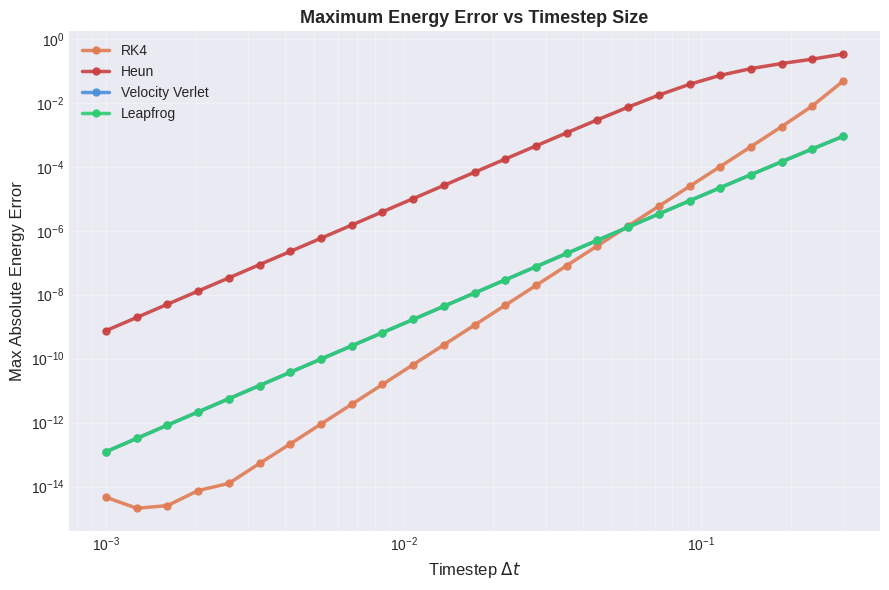

In [ ]:
dt_values  = np.logspace(-3, np.log10(0.3), 25)
test_steps = 3000

max_errors = {name: [] for name in ["RK4", "Heun", "Velocity Verlet", "Leapfrog"]}

for dt_test in dt_values:
    for name in max_errors:
        xs, ys, vxs, vys = run_integrator(name, steps=test_steps, dt=dt_test)
        E = specific_energy(xs, ys, vxs, vys)
        max_errors[name].append(np.max(np.abs(E - E0)))

fig, ax = plt.subplots(figsize=(9, 6))

for name, errors in max_errors.items():
    ax.loglog(dt_values, errors, color=COLORS[name], lw=2.5, marker='o',
              ms=5, alpha=0.9, label=name)

ax.set_xlabel(r'Timestep $\Delta t$', fontsize=12)
ax.set_ylabel('Max Absolute Energy Error', fontsize=12)
ax.set_title('Maximum Energy Error vs Timestep Size', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('timestep_stability.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The log-log plot of maximum energy error vs $\Delta t$ reveals the convergence order of each integrator:

- **RK4** achieves the smallest errors at small $\Delta t$ by a large margin, with its curve dropping steeply — consistent with fourth-order convergence, where halving the timestep reduces error by a factor of 16.
- **Heun** sits at the top with the largest errors across all timesteps, reflecting the poor energy conservation seen throughout this study.
- **Velocity Verlet** and **Leapfrog** overlap perfectly throughout, both showing second-order convergence and confirming their mathematical equivalence as symplectic schemes.
- At large $\Delta t$, all methods degrade and errors grow large. **Heun** blows up earliest, consistent with its aggressive energy growth.

The difference in slope between RK4 and the second-order methods is clearly visible on the log-log scale — RK4's curve is noticeably steeper, which is the direct visual signature of fourth-order vs second-order convergence. However, as shown throughout this study, higher per-step accuracy does not compensate for secular energy drift in long-time simulations.

## 14. Final Conclusions

This study has demonstrated the qualitative and quantitative differences between symplectic and non-symplectic integrators for Hamiltonian systems. The results are summarized in the table below:

| Integrator | Order | Symplectic | Energy Behavior | Angular Momentum | Radius Stability | Phase Space |
|------------|-------|------------|-----------------|------------------|------------------|-------------|
| **Heun** | 2nd | ✗ | Growing (secular) | Growing (secular) | Spiraling outward | Expanding spiral |
| **RK4** | 4th | ✗ | Slow secular drift | Slow secular drift | Slowly drifting | Nearly closed |
| **Velocity Verlet** | 2nd | ✓ | Bounded oscillations | Bounded oscillations | Stable | Closed circle |
| **Leapfrog** | 2nd | ✓ | Bounded oscillations | Bounded oscillations | Stable | Closed circle |2

### Key Takeaways

1. **Symplecticity matters more than order for long-time simulations.** A second-order symplectic integrator outperforms a fourth-order non-symplectic one over thousands of orbital periods in terms of trajectory fidelity.

2. **Heun's method is inappropriate for orbital mechanics.** Its energy grows monotonically, making it unsuitable for any simulation where long-term stability matters.

3. **RK4 is accurate but not structure-preserving.** It excels for short to medium integrations where precision per step is paramount, but its energy drift accumulates slow but systematic drift over long integration times.

4. **Velocity Verlet and Leapfrog are the methods of choice for orbital dynamics.** Their energy oscillates rather than drifts, and they preserve phase-space structure exactly. They show indistinguishable numerical behavior in all diagnostics, confirming that they are equivalent formulations of the same symplectic integration principle.

5. **Angular momentum and energy tell a consistent story.** Both conserved quantities confirm the same hierarchy of integrator quality, reinforcing that symplectic methods preserve the *geometric structure* of the flow — not just one invariant in isolation.

6. **All second-order methods converge as $\mathcal{O}(\Delta t^2)$**, but the constant prefactor and long-time behavior differ sharply based on whether the method is symplectic.

---

These findings generalize well beyond orbital mechanics: symplectic integrators are the standard choice in molecular dynamics, plasma physics, accelerator design, and any field requiring faithful long-time Hamiltonian dynamics.